<h1 align="center"><b><i>Bank Marketing Analysis and Prediction</i></b></h1>

In [1]:
# DATA IMPORT AND LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# DATA LOADING
# df = pd.read_csv(, sep=';')
df = pd.read_csv("bank-additional-full.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# BASIC EXPLORATORY DATA ANALYSIS (EDA)
print("--- Shape of Dataset (Rows, Columns) ---")
print(df.shape)

print("\n--- Columns in Dataset ---")
print(df.columns.tolist())

print("\n--- Dataset Info (Data Types and Missing Values) ---")
df.info()

print("\n--- Summary Statistics (Numerical Columns) ---")
display(df.describe())

print("\n--- Summary Statistics (Categorical Columns) ---")
display(df.describe(include=['object']))

print("\n--- First 5 Rows (Head) ---")
display(df.head())

print("\n--- Last 5 Rows (Tail) ---")
display(df.tail())

--- Shape of Dataset (Rows, Columns) ---
(41188, 21)

--- Columns in Dataset ---
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

--- Dataset Info (Data Types and Missing Values) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



--- Summary Statistics (Categorical Columns) ---


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548



--- First 5 Rows (Head) ---


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



--- Last 5 Rows (Tail) ---


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [4]:
# DATA CLEANING AND PREPROCESSING
df.replace('unknown', np.nan, inplace=True)
df.drop_duplicates(inplace=True)
df_cleaned = df.dropna(subset=['job', 'marital', 'education', 'housing', 'loan'])
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38234 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             38234 non-null  int64  
 1   job             38234 non-null  object 
 2   marital         38234 non-null  object 
 3   education       38234 non-null  object 
 4   default         30478 non-null  object 
 5   housing         38234 non-null  object 
 6   loan            38234 non-null  object 
 7   contact         38234 non-null  object 
 8   month           38234 non-null  object 
 9   day_of_week     38234 non-null  object 
 10  duration        38234 non-null  int64  
 11  campaign        38234 non-null  int64  
 12  pdays           38234 non-null  int64  
 13  previous        38234 non-null  int64  
 14  poutcome        38234 non-null  object 
 15  emp.var.rate    38234 non-null  float64
 16  cons.price.idx  38234 non-null  float64
 17  cons.conf.idx   38234 non-null  floa

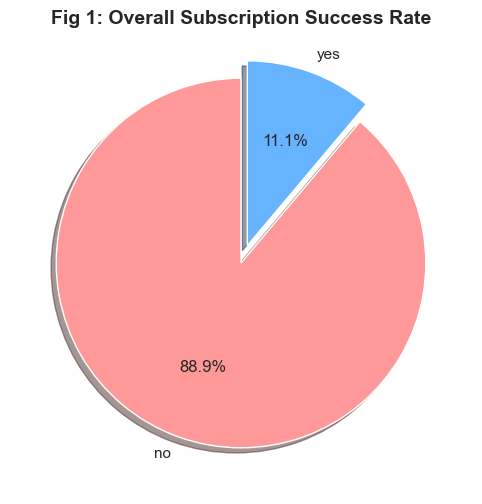

In [5]:
# VISUALIZATION 1: TARGET DISTRIBUTION
plt.figure(figsize=(8, 6))
df_cleaned['y'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', shadow=True, colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Fig 1: Overall Subscription Success Rate', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

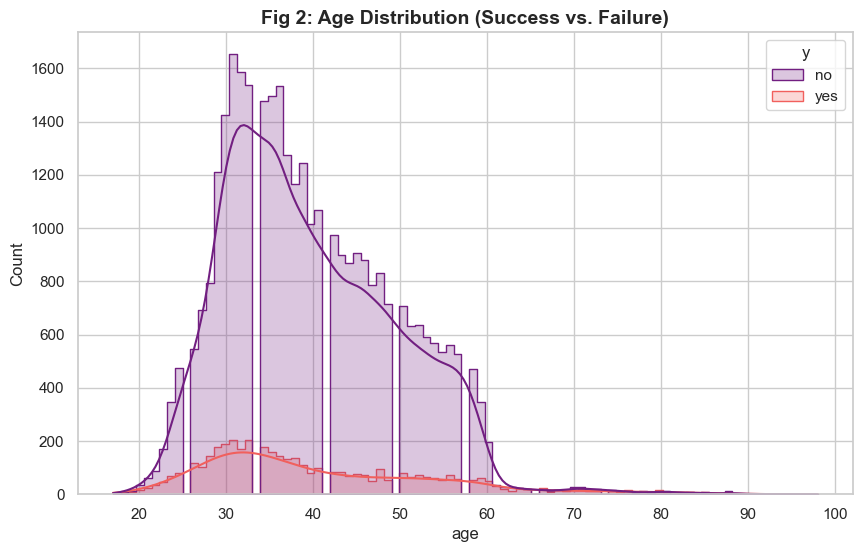

In [6]:
# VISUALIZATION 2: AGE ANALYSIS
plt.figure(figsize=(10, 6))
sns.histplot(data=df_cleaned, x='age', hue='y', kde=True, palette='magma', element="step")
plt.title('Fig 2: Age Distribution (Success vs. Failure)', fontsize=14, fontweight='bold')
plt.show()

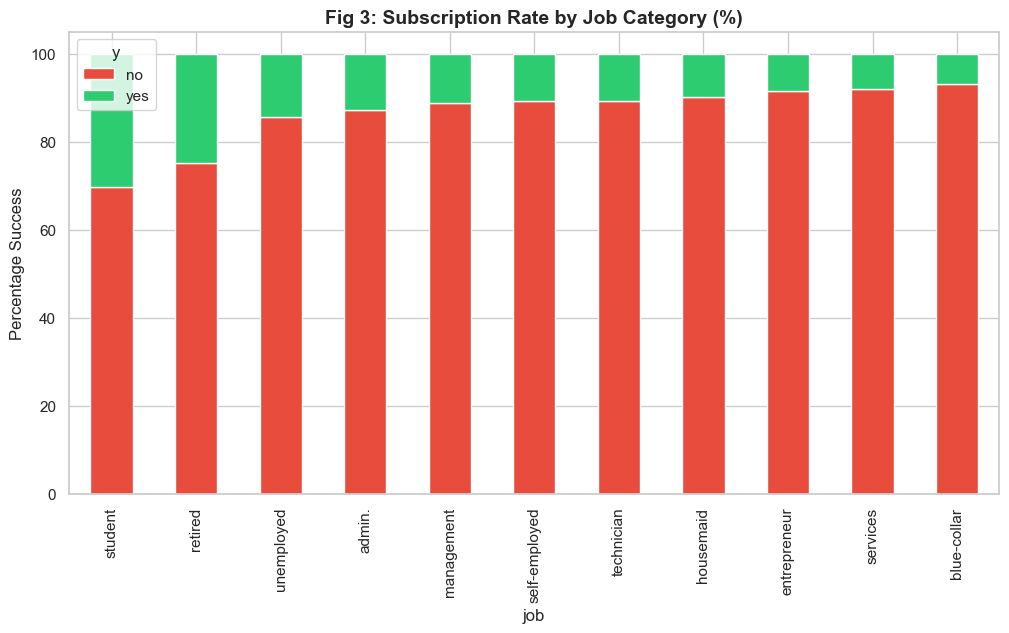

In [7]:
# VISUALIZATION 3: JOB TYPE SUCCESS RATE
job_success = pd.crosstab(df_cleaned['job'], df_cleaned['y'], normalize='index') * 100
job_success.sort_values(by='yes', ascending=False).plot(kind='bar', stacked=True, color=['#e74c3c','#2ecc71'])
plt.title('Fig 3: Subscription Rate by Job Category (%)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage Success')
plt.show()

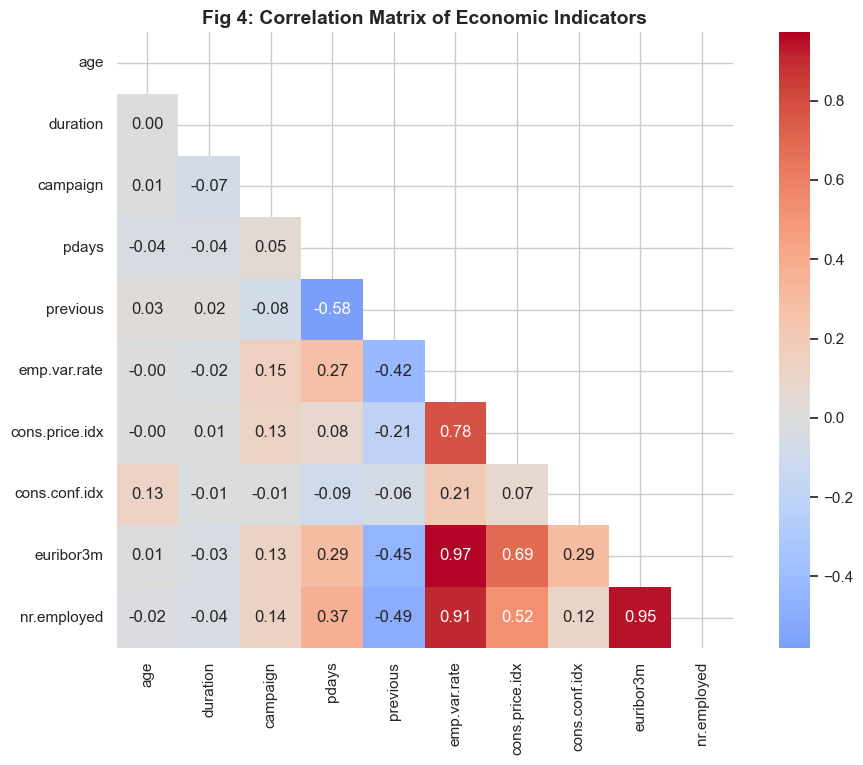

In [8]:
# VISUALIZATION 4: CORRELATION HEATMAP
plt.figure(figsize=(12, 8))
numeric_df = df_cleaned.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title('Fig 4: Correlation Matrix of Economic Indicators', fontsize=14, fontweight='bold')
plt.show()

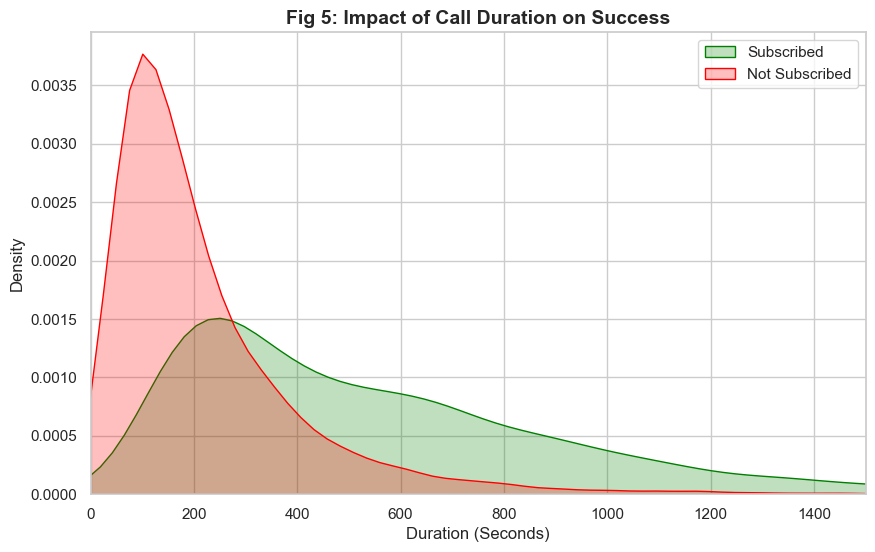

In [9]:
# VISUALIZATION 5: CALL DURATION IMPACT
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_cleaned[df_cleaned['y'] == 'yes'], x='duration', label='Subscribed', fill=True, color='green')
sns.kdeplot(data=df_cleaned[df_cleaned['y'] == 'no'], x='duration', label='Not Subscribed', fill=True, color='red')
plt.xlim(0, 1500)
plt.title('Fig 5: Impact of Call Duration on Success', fontsize=14, fontweight='bold')
plt.xlabel('Duration (Seconds)')
plt.legend()
plt.show()

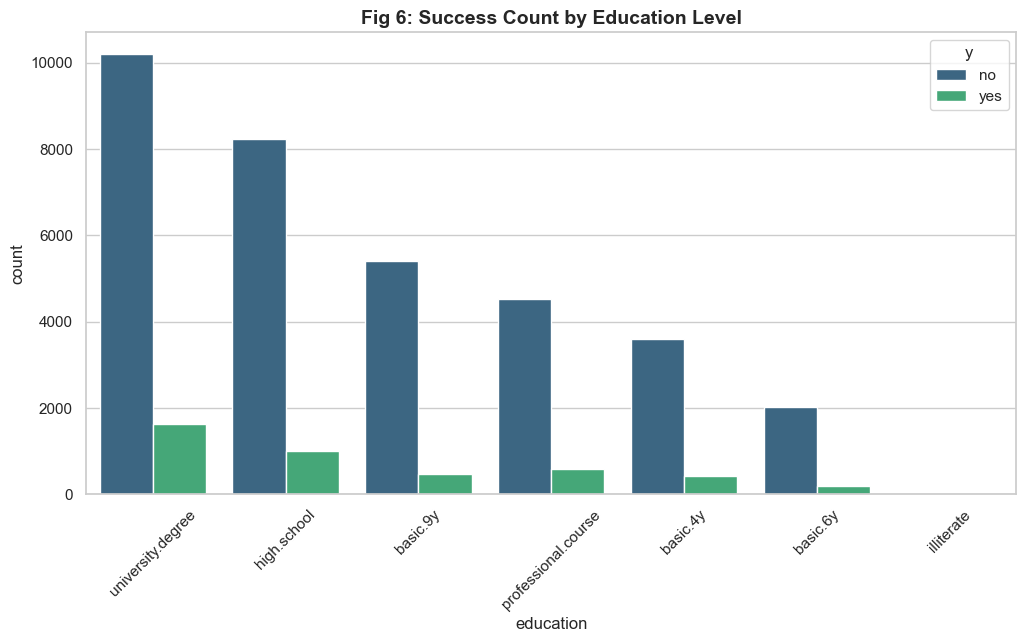

In [10]:
# VISUALIZATION 6: EDUCATION LEVEL PERFORMANCE
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, x='education', hue='y', palette='viridis', order=df_cleaned['education'].value_counts().index)
plt.title('Fig 6: Success Count by Education Level', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

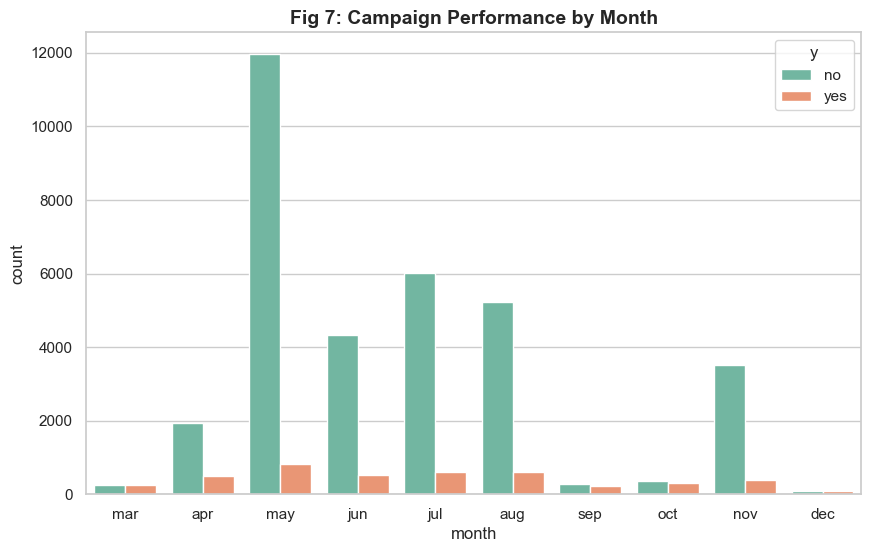

In [11]:
# VISUALIZATION 7: MONTHLY CAMPAIGN TRENDS
plt.figure(figsize=(10, 6))
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
sns.countplot(data=df_cleaned, x='month', hue='y', palette='Set2', order=month_order)
plt.title('Fig 7: Campaign Performance by Month', fontsize=14, fontweight='bold')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2052\2461890358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_cleaned, x='y', y='emp.var.rate', palette='cool')


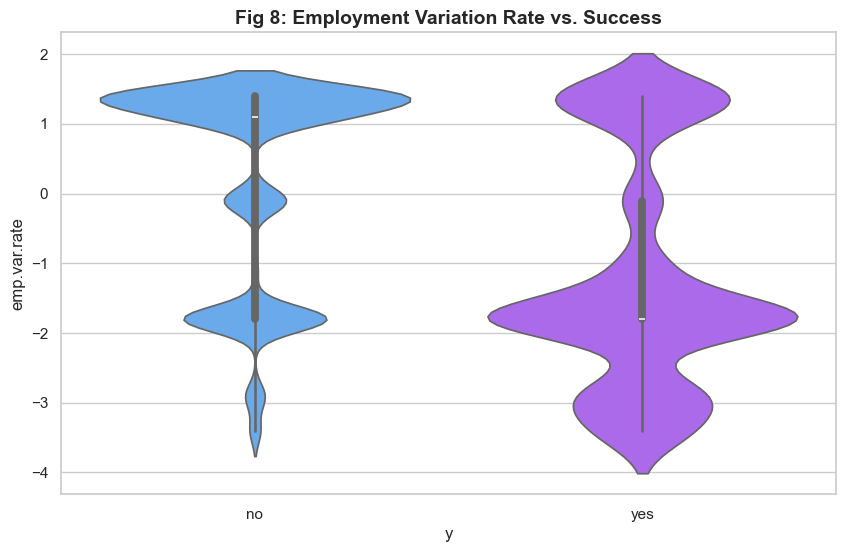

In [12]:
# VISUALIZATION 8: EMPLOYMENT VARIATION RATE
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_cleaned, x='y', y='emp.var.rate', palette='cool')
plt.title('Fig 8: Employment Variation Rate vs. Success', fontsize=14, fontweight='bold')
plt.show()

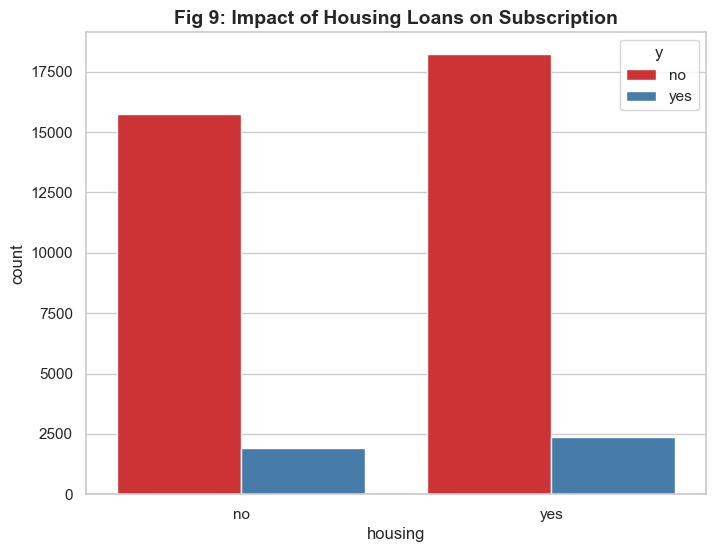

In [13]:
# VISUALIZATION 9: HOUSING LOAN IMPACT
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='housing', hue='y', palette='Set1')
plt.title('Fig 9: Impact of Housing Loans on Subscription', fontsize=14, fontweight='bold')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2052\1353447672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x='contact', y=(df_cleaned['y'] == 'yes').astype(int), palette='autumn')


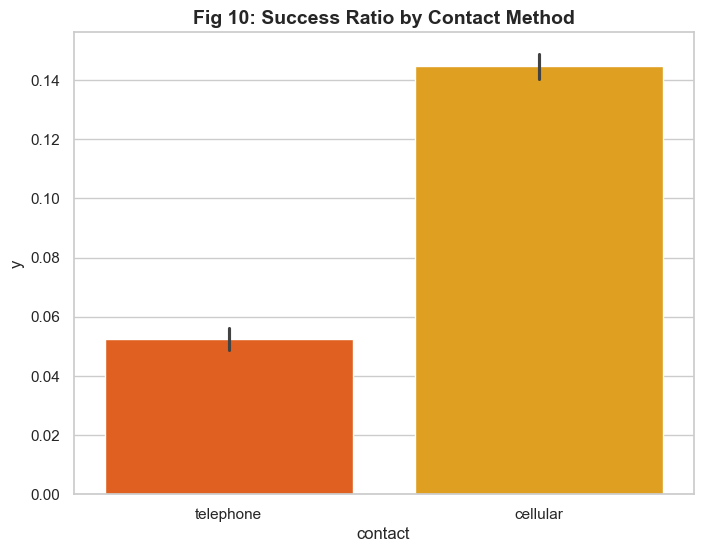

In [14]:
# VISUALIZATION 10: CONTACT METHOD RATIO
plt.figure(figsize=(8, 6))
sns.barplot(data=df_cleaned, x='contact', y=(df_cleaned['y'] == 'yes').astype(int), palette='autumn')
plt.title('Fig 10: Success Ratio by Contact Method', fontsize=14, fontweight='bold')
plt.show()

In [15]:
# MACHINE LEARNING: FEATURE ENCODING
ml_df = df_cleaned.copy()
le = LabelEncoder()
for col in ml_df.select_dtypes(include=['object']).columns:
    ml_df[col] = le.fit_transform(ml_df[col])

X = ml_df.drop('y', axis=1)
y = ml_df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# MACHINE LEARNING: MODEL TRAINING
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

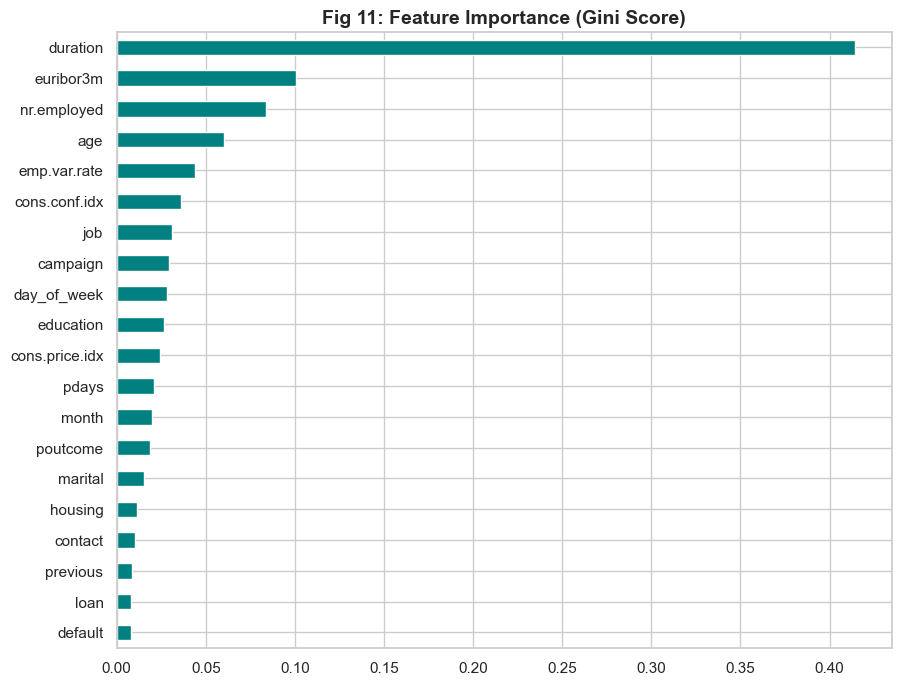

In [17]:
# VISUALIZATION 11: FEATURE IMPORTANCE
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='teal')
plt.title('Fig 11: Feature Importance (Gini Score)', fontsize=14, fontweight='bold')
plt.show()

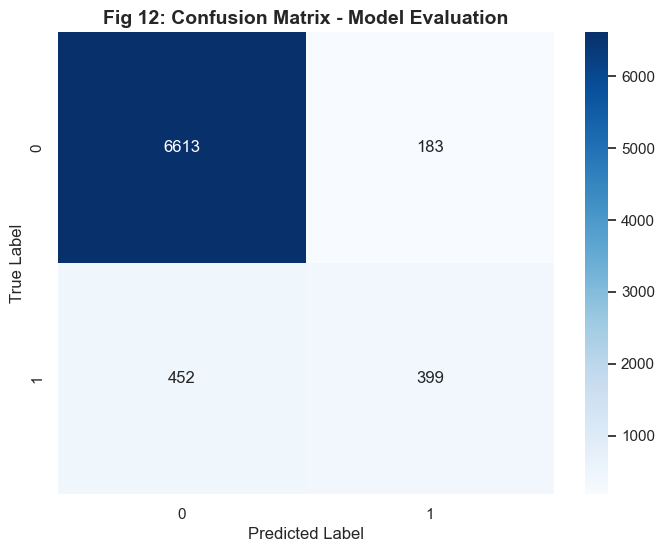

In [18]:
# VISUALIZATION 12: CONFUSION MATRIX
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Fig 12: Confusion Matrix - Model Evaluation', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [19]:
# FINAL MODEL REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      6796
           1       0.69      0.47      0.56       851

    accuracy                           0.92      7647
   macro avg       0.81      0.72      0.76      7647
weighted avg       0.91      0.92      0.91      7647

